In [8]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Load the preprocessed h5ad file
adata = sc.read_h5ad("data/filtered_counts.h5ad")
print(f"Dataset shape: {adata.shape}")

Dataset shape: (14637, 17056)


In [3]:
def plot_gene_expression (adata, obs_key, gene, values=None):
    """
    Plots a violin plot of a gene's expression across specified observation categories.
    
    Parameters:
    - adata: AnnData object (containing unscaled, log-normalized counts)
    - obs_key: The observation column to group by (e.g., 'HSPC_state')
    - gene: The gene of interest (string, e.g., 'Runx1')
    - values: List of categories to include. If None or empty, plots all non-NA categories.
    """
    # 1. Safety check: Verify the gene actually exists in the dataset
    if gene not in adata.var_names:
        print(f"Error: Gene '{gene}' was not found in this dataset. (Is it spelled correctly?)")
        return
    
    # 2. If no values list is provided, find all unique, non-NA values in the dataset
    if values is None or len(values) == 0:
        unique_vals = adata.obs[obs_key].dropna().unique()
        values_to_plot = [v for v in unique_vals if v != 'NA']
    else:
        values_to_plot = values
        
    # 3. Subset the AnnData object to keep only cells belonging to the requested categories
    # (We use .copy() to prevent Pandas/Scanpy setting-with-copy warnings)
    adata_subset = adata[adata.obs[obs_key].isin(values_to_plot)].copy()
    
    # 4. Draw the violin plot
    # use_raw=False forces Scanpy to read from adata_subset.X (our log-normalized counts)
    sc.pl.violin(
        adata_subset, 
        keys=gene, 
        groupby=obs_key, 
        use_raw=False, 
        rotation=45,
    )

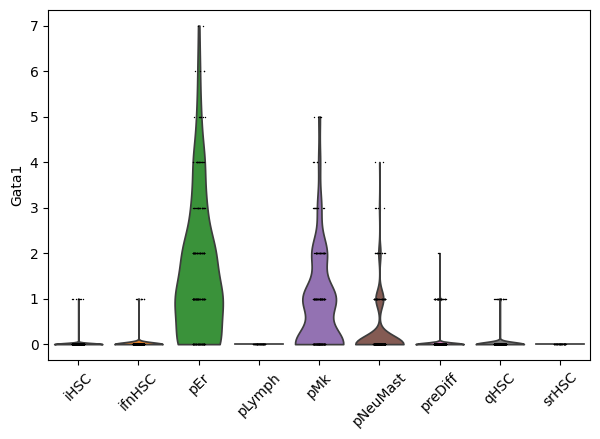

In [5]:
plot_gene_expression(
    adata=adata, 
    obs_key='HSPC_state', 
    gene='Gata1'
)

In [6]:
# Make a copy of the original adata object so that we can access it later if we need to.
adata_original = adata.copy()

# Save the raw counts in a separate layer, as some algorithms also need the raw data
adata.layers['counts'] = adata.X.copy()

# Normalize total counts per cell to 10,000
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmize the data
sc.pp.log1p(adata)

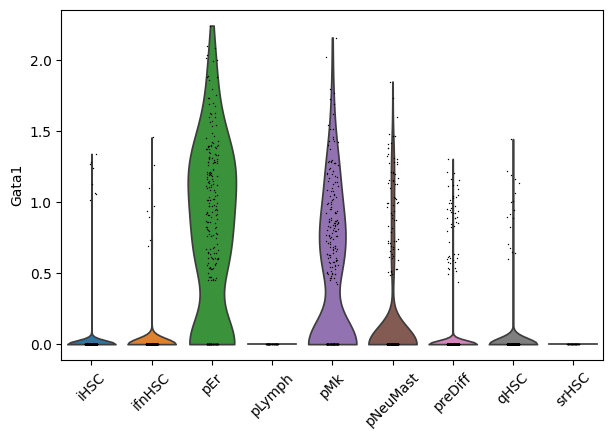

In [7]:
plot_gene_expression(
    adata=adata, 
    obs_key='HSPC_state', 
    gene='Gata1'
)

In [10]:
def assign_boolean_state_kmeans(adata, gene, cell_type_col, threshold_off=0.2, threshold_on=0.8):
    """(Updated to also return cell_df for plotting)"""
    expr = adata[:, gene].X
    if issparse(expr):
        expr = expr.toarray()
    expr = expr.flatten().reshape(-1, 1)
    
    # Run K-means clustering (k=2)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(expr)
    
    # Orient the clusters so 1 is always the high-expression state
    centers = kmeans.cluster_centers_.flatten()
    if centers[0] > centers[1]:
        labels = 1 - labels
        centers = centers[::-1]
        
    cell_df = pd.DataFrame({
        'Cell_Type': adata.obs[cell_type_col].values,
        'Expression': expr.flatten(),
        'Cluster_Label': labels
    })
    
    # Determine 0/1/* per cell type
    results = []
    for ct, group in cell_df.groupby('Cell_Type', observed=True):
        fraction_on = group['Cluster_Label'].mean()
        if fraction_on >= threshold_on:
            state = '1'
        elif fraction_on <= threshold_off:
            state = '0'
        else:
            state = '*'
            
        results.append({
            'Cell_Type': ct,
            'Fraction_ON': fraction_on,
            'State': state
        })
        
    states_df = pd.DataFrame(results)
    
    # Simple QC calculation (subsampled for speed)
    idx = np.random.choice(len(expr), min(len(expr), 10000), replace=False)
    sil_score = silhouette_score(expr[idx], labels[idx])
    qc_metrics = {'Silhouette_Score': round(sil_score, 4)}
    
    return states_df, qc_metrics, cell_df


In [11]:
def plot_kmeans_binarization(cell_df, states_df, gene, threshold_off=0.2, threshold_on=0.8):
    """
    Creates a 2-panel figure visualizing the K-means clustering and cell type state assignments.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Palette configuration
    cluster_colors = {0: '#3498db', 1: '#e74c3c'} # Blue for off, Red for on
    state_colors = {'0': '#3498db', '1': '#e74c3c', '*': '#95a5a6'} # Grey for *
    
    # --- PANEL 1: Expression Distribution ---
    sns.histplot(
        data=cell_df, x='Expression', hue='Cluster_Label', 
        palette=cluster_colors, element='step', bins=50, 
        alpha=0.6, ax=axes[0]
    )
    axes[0].set_yscale('log')
    axes[0].set_title(f"'{gene}' Expression Clusters (k=2)")
    axes[0].set_xlabel("Expression Level")
    axes[0].set_ylabel("Number of Cells")
    
    # --- PANEL 2: Fraction ON per Cell Type ---
    # Sort for prettier plotting
    states_df_sorted = states_df.sort_values('Fraction_ON', ascending=False)
    
    sns.barplot(
        data=states_df_sorted, x='Cell_Type', y='Fraction_ON', 
        hue='State', dodge=False, palette=state_colors, ax=axes[1]
    )
    
    # Draw threshold lines
    axes[1].axhline(threshold_on, color='red', linestyle='--', alpha=0.7, label=f'On Threshold ({threshold_on})')
    axes[1].axhline(threshold_off, color='blue', linestyle='--', alpha=0.7, label=f'Off Threshold ({threshold_off})')
    
    axes[1].set_title(f"Fraction of 'ON' cells per Cell Type")
    axes[1].set_ylabel("Fraction ON")
    axes[1].set_xlabel("")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(loc='upper right', bbox_to_anchor=(1, 1))
    
    # Rotate x-axis labels if there are many cell types
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [12]:
# 1. Filter out actual null/NaN values
valid_cells_mask = adata.obs['HSPC_state'].notna()

# 2. Filter out specific string labels (case-insensitive)
unwanted_labels = ['na', 'nan', 'unknown', 'unassigned']
valid_strings_mask = ~adata.obs['HSPC_state'].astype(str).str.lower().isin(unwanted_labels)

# Apply the masks to create a new, filtered AnnData object
adata_filtered = adata[valid_cells_mask & valid_strings_mask].copy()

In [13]:
adata_filtered

AnnData object with n_obs × n_vars = 5751 × 17056
    obs: 'original_barcode', 'group', 'age', 'sampleName', 'phases', 'G1_score', 'G2M_score', 'S_score', 'AGE', 'numclust', 'HSC_Chambers', 'Bcell_Chambers', 'NK_Chambers', 'NaiveT_Chambers', 'Mono_Chambers', 'Gran_Chambers', 'N.er_Chambers', 'Diff_Chambers', 'Lymph_Chambers', 'Mye_Chambers', 'Mm_HSC_Runx1_Wu', 'Mm_HSC_Tcf7_Wu', 'Mm_HSC_Ivanova', 'Mm_HSC_Ramalho', 'HSC_Explorer', 'Mm_LT_HSC_Venezia', 'Mm_Proliferation_Venezia', 'Mm_Quiescence_Venezia', 'Mm_Adult_HSC_UP_Venezia', 'Polarity_factors_Ting', 'Novel_HSC_regul_polar_Ting', 'Svendsen', 'MGA_MEP', 'priming', 'platform', 'TMC', 'HEM', 'CAM', 'HLOD', 'MHC', 'AgingSvendsen', 'hscScore', 'Pseudotime', 'Monocle_state', 'HSPC_state', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [14]:
gene_of_interest = 'Junb'
t_off = 0.2
t_on = 0.8
states_df, qc, cell_df = assign_boolean_state_kmeans(
    adata_filtered, 
    gene_of_interest, 
    'HSPC_state', 
    threshold_off=t_off, 
    threshold_on=t_on
)

In [15]:
states_df

,Cell_Type,Fraction_ON,State
0,iHSC,0.413150,*
1,ifnHSC,0.426009,*
2,pEr,0.197628,0
3,pLymph,0.646341,*
4,pMk,0.176471,0
5,pNeuMast,0.355000,*
6,preDiff,0.296544,*
7,qHSC,0.933835,1
8,srHSC,0.323529,*


QC Silhouette Score: 0.6943 (Want > 0.5)


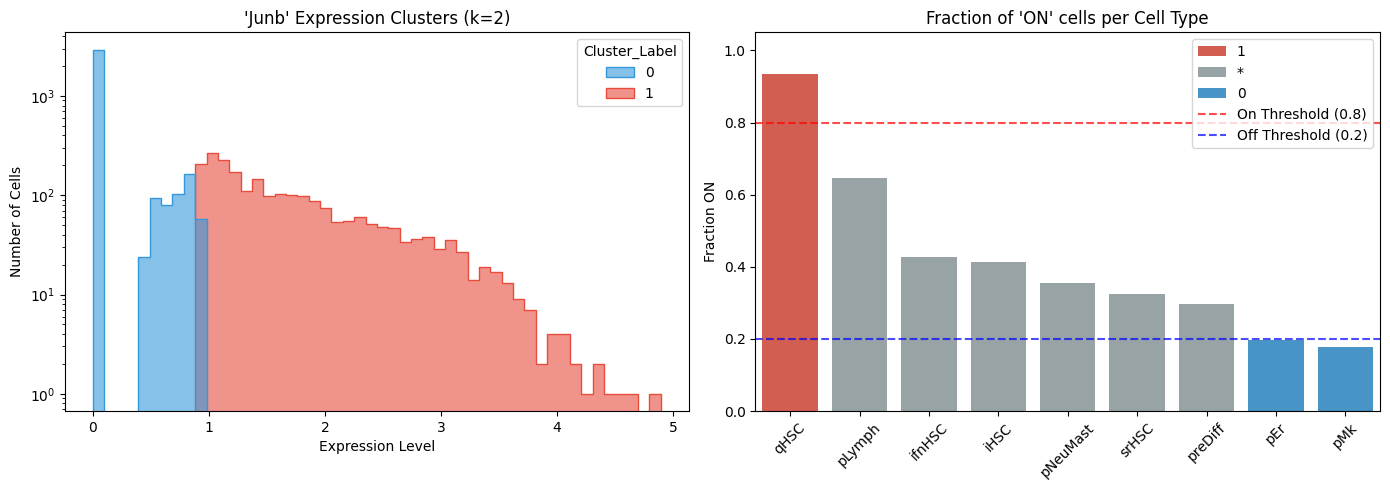

In [16]:
print(f"QC Silhouette Score: {qc['Silhouette_Score']} (Want > 0.5)")

# 4. Plot the results!
plot_kmeans_binarization(
    cell_df, 
    states_df, 
    gene=gene_of_interest, 
    threshold_off=t_off, 
    threshold_on=t_on
)

In [20]:
import pandas as pd

# 1. Configure your inputs
genes_to_process = ["Egr1","Junb","Bclaf1","Myc","Fli1","Gata2","Spi1","Cebpa","Gata1","Klf1","Tal1","Ikzf1","Zfpm1"]
cell_type_column = 'HSPC_state'                       
output_file = 'boolean_grn_matrix.csv'
t_off = 0.2
t_on = 0.6

# 2. Run binarization loop
boolean_states = {}

for gene in genes_to_process:
    if gene not in adata_filtered.var_names:
        print(f"Warning: Gene '{gene}' not found in adata. Skipping.")
        continue
        
    try:
        # Calls your existing function and safely grabs the first output (states_df)
        result = assign_boolean_state_kmeans(
            adata_filtered, 
            gene=gene, 
            cell_type_col=cell_type_column, 
            threshold_off=t_off, 
            threshold_on=t_on
        )
        states_df = result[0]
        
        # Save the state mapped to cell types
        boolean_states[gene] = states_df.set_index('Cell_Type')['State']
        
    except Exception as e:
        print(f"Error processing gene '{gene}': {e}. Skipping.")

# 3. Create the final matrix and export to CSV
# This automatically aligns cell types as rows and sets genes as columns
matrix_df = pd.DataFrame(boolean_states)
matrix_df.to_csv(output_file)

print(f"\nFinished! Output saved to: {output_file}")

# Display the final matrix in your notebook
matrix_df


Finished! Output saved to: boolean_grn_matrix.csv


,Egr1,Junb,Bclaf1,Myc,Fli1,Gata2,Spi1,Cebpa,Gata1,Klf1,Tal1,Ikzf1,Zfpm1
Cell_Type,,,,,,,,,,,,,
iHSC,*,*,*,*,*,*,*,0,0,0,*,0,0
ifnHSC,0,*,*,*,*,*,*,0,0,0,*,*,0
pEr,0,0,1,1,*,*,*,0,1,1,*,*,*
pLymph,*,1,*,0,*,*,*,0,0,0,0,*,0
pMk,0,0,1,*,1,1,*,0,*,0,*,0,*
pNeuMast,0,*,*,*,*,*,1,*,0,0,0,*,0
preDiff,0,*,*,*,*,*,1,0,0,0,*,*,0
qHSC,1,1,*,*,1,1,*,0,0,0,*,*,0
srHSC,0,*,*,*,*,*,*,0,0,0,0,*,0
